<a href="https://colab.research.google.com/github/aswing95/Aswin-projects/blob/master/Python_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/master_sales.csv')
df.head()

,Order ID,Order Date,Year-Month,CustomerName,Segment,Category,Sub-Category,Product,Quantity,Price,Amount,Discount,Profit,PaymentMode,Ship Mode,City,State,Postal Code,Region,Country
0,B-26776,2023-06-27,2023-06,David Padilla,Consumer,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.15,1275.0,UPI,Second Class,Miami,Florida,33161.0,South,United States
1,B-26776,2024-12-27,2024-12,Connor Morgan,Home Office,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.00,1275.0,UPI,Standard Class,Chicago,Illinois,61761.0,Central,United States
2,B-26776,2021-07-25,2021-07,Robert Stone,Corporate,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.20,1275.0,UPI,Standard Class,Buffalo,New York,13021.0,East,United States
3,B-26776,2023-06-27,2023-06,David Padilla,Corporate,Electronics,Printers,Printer,14,355.36,4975.0,0.00,1330.0,UPI,Standard Class,Miami,Florida,33317.0,South,United States
4,B-26776,2024-12-27,2024-12,Connor Morgan,Corporate,Electronics,Printers,Printer,14,355.36,4975.0,0.00,1330.0,UPI,Second Class,Chicago,Illinois,60423.0,Central,United States


### Python Template for Fetching Data from a REST API using `requests`

This template demonstrates how to make a basic GET request to a REST API, handle common HTTP errors, and parse the JSON response. You can adapt it for different API endpoints and request types (POST, PUT, DELETE, etc.).

In [ ]:
import requests
from bs4 import BeautifulSoup

def fetch_webpage_content(url, headers=None):
    """
    Fetches the HTML content of a given URL.

    Args:
        url (str): The URL of the webpage to fetch.
        headers (dict, optional): Dictionary of HTTP headers to send with the request.

    Returns:
        str or None: The HTML content if successful, None otherwise.
    """
    try:
        print(f"Attempting to fetch content from: {url}")
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status() # Raise an exception for HTTP errors
        print(f"Successfully fetched content. Status code: {response.status_code}")
        return response.text
    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL {url}: {e}")
        return None

def parse_html_content(html_content):
    """
    Parses HTML content using BeautifulSoup.

    Args:
        html_content (str): The HTML content as a string.

    Returns:
        BeautifulSoup object or None: A BeautifulSoup object if successful, None otherwise.
    """
    if html_content:
        return BeautifulSoup(html_content, 'html.parser')
    return None

# --- Example Usage ---
print("\n--- Example: Scraping a public Wikipedia page ---")
example_url = 'https://en.wikipedia.org/wiki/Web_scraping'

# It's good practice to set a User-Agent header
custom_headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# 1. Fetch the webpage content
html = fetch_webpage_content(example_url, headers=custom_headers)

if html:
    # 2. Parse the HTML content
    soup = parse_html_content(html)

    if soup:
        print("\nSuccessfully parsed HTML. Extracting some data:")
        # 3. Extract data (example: page title)
        title = soup.find('h1', class_='firstHeading')
        if title:
            print(f"Page Title: {title.get_text(strip=True)}")
        else:
            print("Could not find page title.")

        # 4. Extract some paragraphs
        paragraphs = soup.find_all('p')
        if paragraphs:
            print("\nFirst 3 paragraphs:")
            for i, p in enumerate(paragraphs[:3]):
                print(f"Paragraph {i+1}: {p.get_text(strip=True)[:150]}...") # Print first 150 chars
        else:
            print("Could not find any paragraphs.")

        # 5. Extract all links (hrefs)
        links = soup.find_all('a', href=True)
        if links:
            print(f"\nTotal links found: {len(links)}. First 5 links:")
            for link in links[:5]:
                print(link['href'])
        else:
            print("Could not find any links.")
    else:
        print("Failed to parse HTML.")
else:
    print("Failed to fetch webpage content.")

print("\n--- Example: Extracting a Hypothetical Stock Price ---")
# For demonstration, let's use a hypothetical HTML snippet to show extraction logic.
# In a real scenario, you'd fetch the actual stock page HTML.
hypothetical_stock_html = """
<div class="stock-details">
    <h2 id="stock-name">Acme Corp (ACME)</h2>
    <div class="price-section">
        <span class="current-price">150.75</span>
        <span class="currency">USD</span>
        <span class="change positive">+2.50 (1.68%)</span>
    </div>
    <p class="last-updated">Last updated: 2024-07-26 10:30 AM</p>
</div>
"""

soup_stock = parse_html_content(hypothetical_stock_html)

if soup_stock:
    print("Successfully parsed hypothetical stock HTML.")

    # Extract stock name
    stock_name_tag = soup_stock.find('h2', id='stock-name')
    stock_name = stock_name_tag.get_text(strip=True) if stock_name_tag else 'N/A'
    print(f"Stock Name: {stock_name}")

    # Extract current price
    price_tag = soup_stock.find('span', class_='current-price')
    current_price = price_tag.get_text(strip=True) if price_tag else 'N/A'
    print(f"Current Price: {current_price}")

    # Extract change percentage
    change_tag = soup_stock.find('span', class_='change')
    change_percentage = change_tag.get_text(strip=True) if change_tag else 'N/A'
    print(f"Change: {change_percentage}")
else:
    print("Failed to parse hypothetical stock HTML.")


--- Example: Scraping a public Wikipedia page ---
Attempting to fetch content from: https://en.wikipedia.org/wiki/Web_scraping
Successfully fetched content. Status code: 200

Successfully parsed HTML. Extracting some data:
Page Title: Web scraping

First 3 paragraphs:
Paragraph 1: Web scraping,web harvesting, orweb data extractionisdata scrapingused forextracting datafromwebsites.[1]Web scraping software may directly access theW...
Paragraph 2: Scraping a web page involves fetching it and then extracting data from it. Fetching is the downloading of a page (which a browser does when a user vie...
Paragraph 3: Contact scrapingis a type of web scraping that is used as a component of applications used forweb indexing,web mininganddata mining, online price chan...

Total links found: 460. First 5 links:
#bodyContent
/wiki/Main_Page
/wiki/Wikipedia:Contents
/wiki/Portal:Current_events
/wiki/Special:Random

--- Example: Extracting a Hypothetical Stock Price ---
Successfully parsed hypothetic

### Python Template for Basic Web Scraping using `requests` and `BeautifulSoup`

This template demonstrates how to fetch the HTML content of a webpage and then parse it using BeautifulSoup to extract specific elements. Remember that web scraping should always be done responsibly and in compliance with a website's `robots.txt` file and terms of service.

In [ ]:
import requests
from bs4 import BeautifulSoup

def fetch_webpage_content(url, headers=None):
    """
    Fetches the HTML content of a given URL.

    Args:
        url (str): The URL of the webpage to fetch.
        headers (dict, optional): Dictionary of HTTP headers to send with the request.

    Returns:
        str or None: The HTML content if successful, None otherwise.
    """
    try:
        print(f"Attempting to fetch content from: {url}")
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status() # Raise an exception for HTTP errors
        print(f"Successfully fetched content. Status code: {response.status_code}")
        return response.text
    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL {url}: {e}")
        return None

def parse_html_content(html_content):
    """
    Parses HTML content using BeautifulSoup.

    Args:
        html_content (str): The HTML content as a string.

    Returns:
        BeautifulSoup object or None: A BeautifulSoup object if successful, None otherwise.
    """
    if html_content:
        return BeautifulSoup(html_content, 'html.parser')
    return None

# --- Example Usage ---
print("\n--- Example: Scraping a public Wikipedia page ---")
example_url = 'https://en.wikipedia.org/wiki/Web_scraping'

# It's good practice to set a User-Agent header
custom_headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
}

# 1. Fetch the webpage content
html = fetch_webpage_content(example_url, headers=custom_headers)

if html:
    # 2. Parse the HTML content
    soup = parse_html_content(html)

    if soup:
        print("\nSuccessfully parsed HTML. Extracting some data:")
        # 3. Extract data (example: page title)
        title = soup.find('h1', class_='firstHeading')
        if title:
            print(f"Page Title: {title.get_text(strip=True)}")
        else:
            print("Could not find page title.")

        # 4. Extract some paragraphs
        paragraphs = soup.find_all('p')
        if paragraphs:
            print("\nFirst 3 paragraphs:")
            for i, p in enumerate(paragraphs[:3]):
                print(f"Paragraph {i+1}: {p.get_text(strip=True)[:150]}...") # Print first 150 chars
        else:
            print("Could not find any paragraphs.")

        # 5. Extract all links (hrefs)
        links = soup.find_all('a', href=True)
        if links:
            print(f"\nTotal links found: {len(links)}. First 5 links:")
            for link in links[:5]:
                print(link['href'])
        else:
            print("Could not find any links.")
    else:
        print("Failed to parse HTML.")
else:
    print("Failed to fetch webpage content.")


--- Example: Scraping a public Wikipedia page ---
Attempting to fetch content from: https://en.wikipedia.org/wiki/Web_scraping
Successfully fetched content. Status code: 200

Successfully parsed HTML. Extracting some data:
Page Title: Web scraping

First 3 paragraphs:
Paragraph 1: Web scraping,web harvesting, orweb data extractionisdata scrapingused forextracting datafromwebsites.[1]Web scraping software may directly access theW...
Paragraph 2: Scraping a web page involves fetching it and then extracting data from it. Fetching is the downloading of a page (which a browser does when a user vie...
Paragraph 3: Contact scrapingis a type of web scraping that is used as a component of applications used forweb indexing,web mininganddata mining, online price chan...

Total links found: 460. First 5 links:
#bodyContent
/wiki/Main_Page
/wiki/Wikipedia:Contents
/wiki/Portal:Current_events
/wiki/Special:Random


In [ ]:
import requests
import json

def fetch_data_from_api(url, params=None, headers=None):
    """
    Fetches data from a given REST API URL.

    Args:
        url (str): The URL of the API endpoint.
        params (dict, optional): Dictionary of query parameters to send with the request.
        headers (dict, optional): Dictionary of HTTP headers to send with the request.

    Returns:
        dict or None: The JSON response data if successful, None otherwise.
    """
    try:
        print(f"Attempting to fetch data from: {url}")

        # Make the GET request
        response = requests.get(url, params=params, headers=headers, timeout=10)

        # Raise an HTTPError for bad responses (4xx or 5xx)
        response.raise_for_status()

        print(f"Successfully fetched data. Status code: {response.status_code}")

        # Parse the JSON response
        data = response.json()
        return data

    except requests.exceptions.HTTPError as http_err:
        print(f"HTTP error occurred: {http_err}")  # e.g. 404 Not Found, 500 Internal Server Error
    except requests.exceptions.ConnectionError as conn_err:
        print(f"Connection error occurred: {conn_err}") # e.g. DNS failure, refused connection
    except requests.exceptions.Timeout as timeout_err:
        print(f"Timeout error occurred: {timeout_err}")    # e.g. server did not respond in time
    except requests.exceptions.RequestException as req_err:
        print(f"An unexpected error occurred: {req_err}")
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from response: {response.text[:200]}...") # show first 200 chars

    return None

# --- Example Usage ---

# 1. Public API without authentication (e.g., JSONPlaceholder for fake data)
print("\n--- Example 1: Public API (JSONPlaceholder) ---")
jsonplaceholder_url = 'https://jsonplaceholder.typicode.com/posts/1'
post_data = fetch_data_from_api(jsonplaceholder_url)
if post_data:
    print("Fetched Post Data:")
    print(json.dumps(post_data, indent=2))

# 2. Public API with query parameters (e.g., another JSONPlaceholder endpoint)
print("\n--- Example 2: API with Query Parameters ---")
todos_url = 'https://jsonplaceholder.typicode.com/todos'
todos_params = {'userId': 1, 'completed': 'false'}
filtered_todos = fetch_data_from_api(todos_url, params=todos_params)
if filtered_todos:
    print(f"Fetched {len(filtered_todos)} uncompleted todos for userId 1:")
    # print(json.dumps(filtered_todos, indent=2)) # Uncomment to see all data
    print(f"First todo: {filtered_todos[0]['title']}")

# 3. Example of a (hypothetical) API requiring an API key in headers
#    (Replace 'YOUR_API_KEY' and 'your_api_endpoint' with actual values)
# print("\n--- Example 3: API with Headers (Authentication) ---")
# authenticated_api_url = 'https://api.example.com/data'
# api_key = 'YOUR_API_KEY' # In a real application, get this from environment variables or a secrets manager
# auth_headers = {
#     'Authorization': f'Bearer {api_key}', # Common for token-based auth
#     'Accept': 'application/json'
# }
# secured_data = fetch_data_from_api(authenticated_api_url, headers=auth_headers)
# if secured_data:
#     print("Fetched Secured Data:")
#     print(json.dumps(secured_data, indent=2))

# 4. Example of an invalid URL to demonstrate error handling
print("\n--- Example 4: Invalid URL (Error Handling) ---")
invalid_url = 'https://this-is-not-a-real-domain.com/data'
error_example = fetch_data_from_api(invalid_url)
if error_example is None:
    print("Error handling for invalid URL worked as expected.")

# 5. Example of a non-existent endpoint on a valid domain
print("\n--- Example 5: Non-existent Endpoint (HTTPError) ---")
not_found_url = 'https://jsonplaceholder.typicode.com/nonexistent-endpoint'
not_found_example = fetch_data_from_api(not_found_url)
if not_found_example is None:
    print("Error handling for non-existent endpoint (404) worked as expected.")


--- Example 1: Public API (JSONPlaceholder) ---
Attempting to fetch data from: https://jsonplaceholder.typicode.com/posts/1
Successfully fetched data. Status code: 200
Fetched Post Data:
{
  "userId": 1,
  "id": 1,
  "title": "sunt aut facere repellat provident occaecati excepturi optio reprehenderit",
  "body": "quia et suscipit\nsuscipit recusandae consequuntur expedita et cum\nreprehenderit molestiae ut ut quas totam\nnostrum rerum est autem sunt rem eveniet architecto"
}

--- Example 2: API with Query Parameters ---
Attempting to fetch data from: https://jsonplaceholder.typicode.com/todos
Successfully fetched data. Status code: 200
Fetched 9 uncompleted todos for userId 1:
First todo: delectus aut autem

--- Example 4: Invalid URL (Error Handling) ---
Attempting to fetch data from: https://this-is-not-a-real-domain.com/data
Connection error occurred: HTTPSConnectionPool(host='this-is-not-a-real-domain.com', port=443): Max retries exceeded with url: /data (Caused by NameResolutionE

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11557 entries, 0 to 11556
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      11557 non-null  object 
 1   Order Date    11557 non-null  object 
 2   Year-Month    11557 non-null  object 
 3   CustomerName  11557 non-null  object 
 4   Segment       11557 non-null  object 
 5   Category      11557 non-null  object 
 6   Sub-Category  11557 non-null  object 
 7   Product       11557 non-null  object 
 8   Quantity      11557 non-null  int64  
 9   Price         11557 non-null  float64
 10  Amount        11557 non-null  float64
 11  Discount      11557 non-null  float64
 12  Profit        11557 non-null  float64
 13  PaymentMode   11557 non-null  object 
 14  Ship Mode     11557 non-null  object 
 15  City          11557 non-null  object 
 16  State         11557 non-null  object 
 17  Postal Code   11557 non-null  float64
 18  Region        11557 non-nu

In [ ]:
df.isnull().sum()

,0
Order ID,0
Order Date,0
Year-Month,0
CustomerName,0
Segment,0
Category,0
Sub-Category,0
Product,0
Quantity,0
Price,0


In [ ]:
df[df.duplicated()]

,Order ID,Order Date,Year-Month,CustomerName,Segment,Category,Sub-Category,Product,Quantity,Price,Amount,Discount,Profit,PaymentMode,Ship Mode,City,State,Postal Code,Region,Country


In [ ]:
df.describe()

,Quantity,Price,Amount,Discount,Profit,Postal Code
count,11557.000000,11557.000000,11557.000000,11557.000000,11557.000000,11557.000000
mean,4.843731,164.222663,799.717302,0.156141,181.874543,54879.776153
std,4.190201,527.524027,1891.365484,0.206151,596.225023,31539.688226
min,1.000000,0.990000,0.444000,0.000000,-6599.978000,1040.000000
25%,2.000000,7.300000,20.416000,0.000000,2.702800,27217.000000
50%,3.000000,29.990000,79.960000,0.200000,12.096000,55901.000000
75%,6.000000,125.990000,443.920000,0.200000,66.627200,90004.000000
max,50.000000,9894.000000,22638.480000,0.800000,8399.976000,99301.000000


<Axes: >

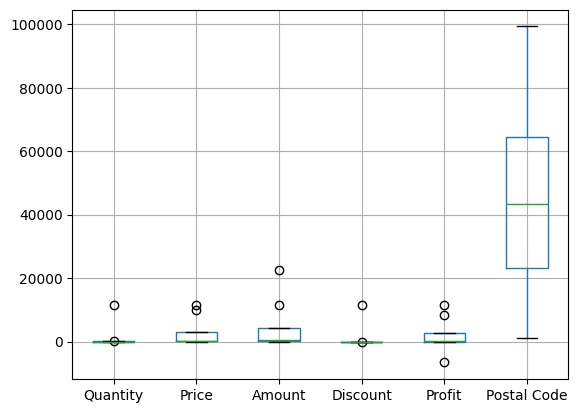

In [ ]:
df.describe().boxplot()

In [ ]:
print(f"Shape of df after outlier removal: {df.shape}")

Shape of df after outlier removal: (11557, 20)


In [ ]:
df.head()

,Order ID,Order Date,Year-Month,CustomerName,Segment,Category,Sub-Category,Product,Quantity,Price,Amount,Discount,Profit,PaymentMode,Ship Mode,City,State,Postal Code,Region,Country
0,B-26776,2023-06-27,2023-06,David Padilla,Consumer,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.15,1275.0,UPI,Second Class,Miami,Florida,33161.0,South,United States
1,B-26776,2024-12-27,2024-12,Connor Morgan,Home Office,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.00,1275.0,UPI,Standard Class,Chicago,Illinois,61761.0,Central,United States
2,B-26776,2021-07-25,2021-07,Robert Stone,Corporate,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.20,1275.0,UPI,Standard Class,Buffalo,New York,13021.0,East,United States
3,B-26776,2023-06-27,2023-06,David Padilla,Corporate,Electronics,Printers,Printer,14,355.36,4975.0,0.00,1330.0,UPI,Standard Class,Miami,Florida,33317.0,South,United States
4,B-26776,2024-12-27,2024-12,Connor Morgan,Corporate,Electronics,Printers,Printer,14,355.36,4975.0,0.00,1330.0,UPI,Second Class,Chicago,Illinois,60423.0,Central,United States


In [ ]:
df.shape

(11557, 20)

### Counting Outlier Rows using IQR Method

In [ ]:
df_temp = df.copy()

initial_rows = df_temp.shape[0]

numerical_cols = df_temp.select_dtypes(include=['number']).columns

for col in numerical_cols:
    Q1 = df_temp[col].quantile(0.25)
    Q3 = df_temp[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_temp = df_temp[(df_temp[col] >= lower_bound) & (df_temp[col] <= upper_bound)]

rows_after_outlier_identification = df_temp.shape[0]
num_outlier_rows = initial_rows - rows_after_outlier_identification

print(f"Initial number of rows in the DataFrame: {initial_rows}")
print(f"Number of rows after identifying and hypothetically removing outliers: {rows_after_outlier_identification}")
print(f"Number of rows identified as outliers (would be removed): {num_outlier_rows}")

Initial number of rows in the DataFrame: 11557
Number of rows after identifying and hypothetically removing outliers: 6615
Number of rows identified as outliers (would be removed): 4942


### Displaying Outlier Rows

In [ ]:
df_outliers = df.copy()
initial_rows = df_outliers.shape[0]

numerical_cols = df_outliers.select_dtypes(include=['number']).columns

# Create a boolean mask to keep track of non-outlier rows
non_outlier_mask = pd.Series(True, index=df_outliers.index)

for col in numerical_cols:
    Q1 = df_outliers[col].quantile(0.25)
    Q3 = df_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Update the mask: if a row is an outlier in this column, set its mask value to False
    # We want rows that are *not* within the bounds
    col_outlier_mask = ~((df_outliers[col] >= lower_bound) & (df_outliers[col] <= upper_bound))
    non_outlier_mask = non_outlier_mask & col_outlier_mask # This should be OR, to find any outlier across columns

# Corrected logic for identifying outliers across *any* numerical column
# Let's re-do the outlier identification for clarity and correctness

outlier_indices = pd.Index([])

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Get indices of outliers for the current column
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outlier_indices = outlier_indices.union(col_outliers)

# Select the outlier rows using the collected indices
outlier_rows = df.loc[outlier_indices]

print(f"Number of outlier rows identified: {len(outlier_rows)}")
display(outlier_rows.head())

Number of outlier rows identified: 3363


,Order ID,Order Date,Year-Month,CustomerName,Segment,Category,Sub-Category,Product,Quantity,Price,Amount,Discount,Profit,PaymentMode,Ship Mode,City,State,Postal Code,Region,Country
0,B-26776,2023-06-27,2023-06,David Padilla,Consumer,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.15,1275.0,UPI,Second Class,Miami,Florida,33161.0,South,United States
1,B-26776,2024-12-27,2024-12,Connor Morgan,Home Office,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.00,1275.0,UPI,Standard Class,Chicago,Illinois,61761.0,Central,United States
2,B-26776,2021-07-25,2021-07,Robert Stone,Corporate,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.20,1275.0,UPI,Standard Class,Buffalo,New York,13021.0,East,United States
3,B-26776,2023-06-27,2023-06,David Padilla,Corporate,Electronics,Printers,Printer,14,355.36,4975.0,0.00,1330.0,UPI,Standard Class,Miami,Florida,33317.0,South,United States
4,B-26776,2024-12-27,2024-12,Connor Morgan,Corporate,Electronics,Printers,Printer,14,355.36,4975.0,0.00,1330.0,UPI,Second Class,Chicago,Illinois,60423.0,Central,United States


### Explaining Outlier Values

### Capping Outliers using IQR Method

In [ ]:
df_capped = df_outliers.copy() # Using df_outliers as it's a copy of the original df before any removals

numerical_cols = df_capped.select_dtypes(include=['number']).columns

print("Before capping:\n")

display(df_capped[numerical_cols].describe())

for col in numerical_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values at the lower and upper bounds
    df_capped[col] = df_capped[col].clip(lower=lower_bound, upper=upper_bound)

print("\nAfter capping:\n")
display(df_capped[numerical_cols].describe())


print(f"Shape of DataFrame after capping outliers: {df_capped.shape}")
print("Note: No rows were removed. Only extreme values in numerical columns were adjusted.")

Before capping:



,Quantity,Price,Amount,Discount,Profit,Postal Code
count,11557.000000,11557.000000,11557.000000,11557.000000,11557.000000,11557.000000
mean,4.843731,164.222663,799.717302,0.156141,181.874543,54879.776153
std,4.190201,527.524027,1891.365484,0.206151,596.225023,31539.688226
min,1.000000,0.990000,0.444000,0.000000,-6599.978000,1040.000000
25%,2.000000,7.300000,20.416000,0.000000,2.702800,27217.000000
50%,3.000000,29.990000,79.960000,0.200000,12.096000,55901.000000
75%,6.000000,125.990000,443.920000,0.200000,66.627200,90004.000000
max,50.000000,9894.000000,22638.480000,0.800000,8399.976000,99301.000000



After capping:



,Quantity,Price,Amount,Discount,Profit,Postal Code
count,11557.000000,11557.000000,11557.000000,11557.000000,11557.000000,11557.000000
mean,4.498832,84.158944,295.072963,0.137537,39.212506,54879.776153
std,3.025323,105.049930,389.210262,0.157788,66.643261,31539.688226
min,1.000000,0.990000,0.444000,0.000000,-93.183800,1040.000000
25%,2.000000,7.300000,20.416000,0.000000,2.702800,27217.000000
50%,3.000000,29.990000,79.960000,0.200000,12.096000,55901.000000
75%,6.000000,125.990000,443.920000,0.200000,66.627200,90004.000000
max,12.000000,304.025000,1079.176000,0.500000,162.513800,99301.000000


Shape of DataFrame after capping outliers: (11557, 20)
Note: No rows were removed. Only extreme values in numerical columns were adjusted.


In [ ]:


# Re-calculate bounds using the state of df when outlier_rows was created
# (assuming df_outliers from the previous cell holds the original dataframe before any removals)
# If df has been modified significantly, we would need to reload or work with a pristine copy.
# For this explanation, we'll use df_outliers which was a copy of the df *before* permanent outlier removal.

def get_outlier_reasons(row, numerical_cols, original_df_for_bounds):
    reasons = []
    for col in numerical_cols:
        Q1 = original_df_for_bounds[col].quantile(0.25)
        Q3 = original_df_for_bounds[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        value = row[col]
        if not (lower_bound <= value <= upper_bound):
            reasons.append(f"{col}: {value} (Outside [{lower_bound:.2f}, {upper_bound:.2f}])")
    return '; '.join(reasons) if reasons else "No clear numerical outlier by IQR in displayed columns"

# Use df_outliers for calculating the bounds, as this was the reference when outlier_rows was determined.
# The df_outliers in kernel state is a copy of the df before it was shrunk.

numerical_cols_for_explanation = df_outliers.select_dtypes(include=['number']).columns

# Apply the function to the head of the identified outlier rows for a detailed explanation
# Adjust the number of rows displayed by head() as needed
explanation_df = outlier_rows.head(5).copy()
explanation_df['Outlier Reasons'] = explanation_df.apply(
    lambda row: get_outlier_reasons(row, numerical_cols_for_explanation, df_outliers),
    axis=1
)

print("Here are the specific reasons why the first 5 identified outlier rows were flagged:")
display(explanation_df[['Order ID'] + numerical_cols_for_explanation.tolist() + ['Outlier Reasons']])

Here are the specific reasons why the first 5 identified outlier rows were flagged:


,Order ID,Quantity,Price,Amount,Discount,Profit,Postal Code,Outlier Reasons
0,B-26776,5,1945.20,9726.0,0.15,1275.0,33161.0,"Price: 1945.2 (Outside [-170.73, 304.02]); Amo..."
1,B-26776,5,1945.20,9726.0,0.00,1275.0,61761.0,"Price: 1945.2 (Outside [-170.73, 304.02]); Amo..."
2,B-26776,5,1945.20,9726.0,0.20,1275.0,13021.0,"Price: 1945.2 (Outside [-170.73, 304.02]); Amo..."
3,B-26776,14,355.36,4975.0,0.00,1330.0,33317.0,"Quantity: 14 (Outside [-4.00, 12.00]); Price: ..."
4,B-26776,14,355.36,4975.0,0.00,1330.0,60423.0,"Quantity: 14 (Outside [-4.00, 12.00]); Price: ..."


Exploratory Data Analysis

In [ ]:
df.shape

(11557, 20)

In [ ]:
# Group by Segment, but only calculate the sum for the Price column
df.groupby('Segment')['Amount'].sum().sort_values(ascending=False)

,Amount
Segment,
Consumer,4.759590e+06
Corporate,2.834610e+06
Home Office,1.648132e+06


The result shows the total sales Amount for each customer Segment, sorted from the highest total sales to the lowest.

From this output, we can see that:

The Consumer segment has the highest total sales, with approximately 4.76 million.
The Corporate segment comes in second with about 2.83 million in total sales.
The Home Office segment has the lowest total sales, around 1.65 million.
This gives you an immediate overview of which customer segments are contributing the most to your overall sales revenue.

In [ ]:

df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

,Amount
Category,
Office Supplies,2.808557e+06
Furniture,2.780673e+06
Electronics,2.570536e+06
Technology,8.361540e+05
Accessories,1.088630e+05
Clothing,9.555000e+04
Shoes,2.160000e+04
Bags,2.040000e+04


Key observations from this result are:

Electronics - Smartphone has the highest total sales amount of 937,455.00.
Other products with significant sales amounts include Furniture - Table, Furniture - Chair, and Office Supplies - Marker.
This table provides a clear view of which product categories and individual products are contributing the most to the overall sales revenue.


In [ ]:
pivot = df.pivot_table(index=['Category', 'Product'],
                       values='Profit',
                       aggfunc='sum').sort_values(by='Profit', ascending=False)

print(pivot)


                                    Profit
Category        Product                   
Electronics     Smartphone     234770.3900
Office Supplies Paper Pack     183776.5693
                Marker         174749.0000
Furniture       Chair          149482.1663
Electronics     Smartwatch     148454.0000
                Printer        146259.0000
Furniture       Sofa           142854.0000
                Table          139070.5189
Office Supplies Pen            129846.0000
                Binder         127478.7633
Furniture       Bookcase       114527.4440
Electronics     Laptop         111703.8600
Technology      Copier          55617.8249
                Smartphone      44515.7306
                Accessory       41936.6357
Office Supplies Storage Box     21278.8264
                Appliance       18138.0054
Accessories     Smartwatch      17583.8900
Furniture       Furnishing      13059.1436
Electronics     Speaker          9895.5400
Clothing        Coat             8837.9500
Office Supp

In [ ]:
correlation_matrix = df[['Amount', 'Profit']].corr()
display(correlation_matrix)

,Amount,Profit
Amount,1.000000,0.825307
Profit,0.825307,1.000000


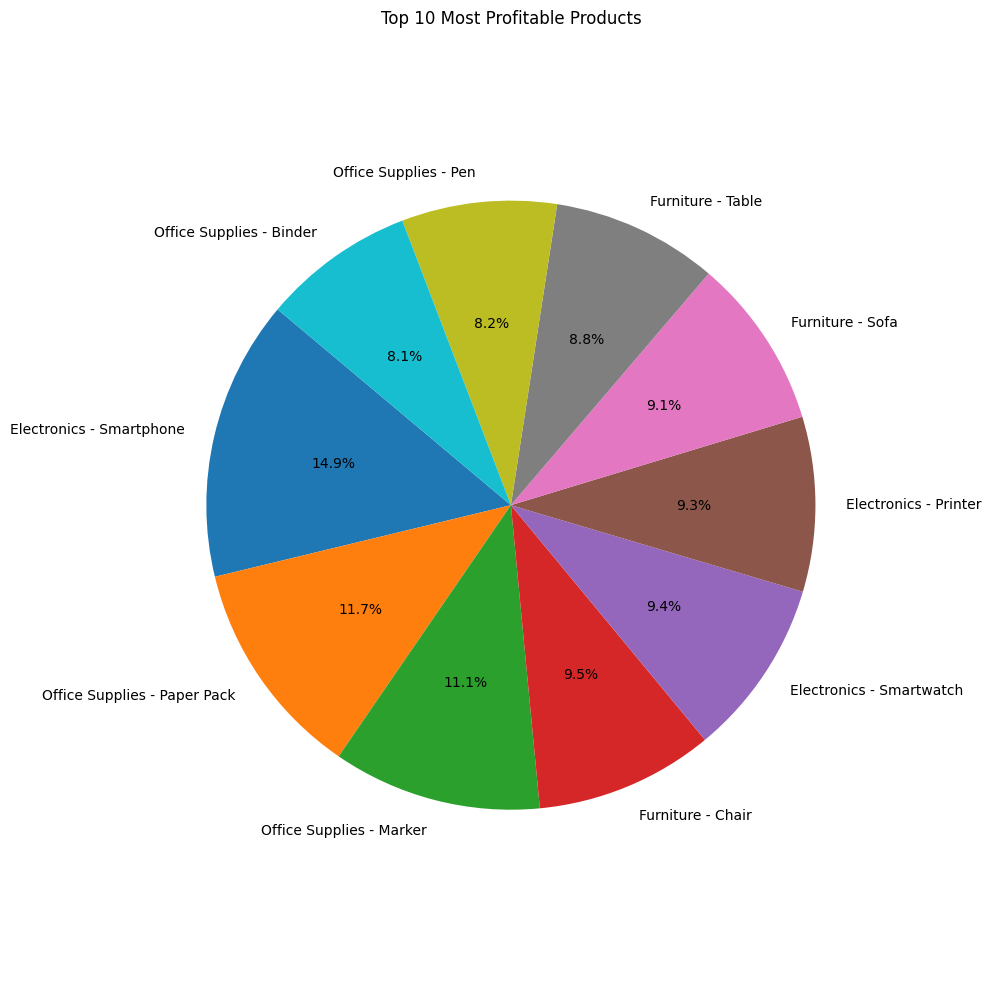

In [ ]:
profit_pivot = df.pivot_table(index=['Category', 'Product'], values='Profit', aggfunc='sum').sort_values(by='Profit', ascending=False)

top_10_profit_products = profit_pivot.head(10).reset_index()
top_10_profit_products['Category_Product'] = top_10_profit_products['Category'] + ' - ' + top_10_profit_products['Product']

plt.figure(figsize=(10, 10))
plt.pie(top_10_profit_products['Profit'], labels=top_10_profit_products['Category_Product'], autopct='%1.1f%%', startangle=140)
plt.title('Top 10 Most Profitable Products')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

The output you see is a pivot table that summarizes the total Profit for each Product within its respective Category. It's sorted in descending order, meaning the products and categories with the highest total profit appear at the top.

From this table, we can observe:

Electronics and Office Supplies categories contain the most profitable products.
The top 3 most profitable products are Smartphone (under Electronics), Paper Pack (under Office Supplies), and Marker (under Office Supplies).
The Profit column indicates the sum of profits generated by each specific product across all orders.
The output displays a pivot table that summarizes the total Profit for each Product within its corresponding Category, sorted from the highest profit to the lowest.

Key observations from this result are:

Electronics - Smartphone is the most profitable product with a profit of 234,770.39.
Other high-profit items include Office Supplies - Paper Pack and Office Supplies - Marker.
Interestingly, Office Supplies - Office Supply shows a negative profit of -1,189.0995, indicating a loss.

In [ ]:
pivot = df.pivot_table(index=['Category', 'Product'],
                       values='Amount',
                       aggfunc='sum').sort_values(by='Amount', ascending=False)

print(pivot)

                                    Amount
Category        Product                   
Electronics     Smartphone     937455.0000
Furniture       Table          832142.5320
                Chair          760413.1030
Office Supplies Marker         627875.0000
                Paper Pack     603234.2060
                Binder         588023.7330
Furniture       Sofa           568367.0000
Electronics     Printer        566359.0000
                Smartwatch     565092.0000
Office Supplies Pen            552269.0000
Furniture       Bookcase       528044.9963
Electronics     Laptop         425950.0000
Technology      Smartphone     330007.0540
Office Supplies Storage Box    223843.6080
Technology      Machine        189238.6310
                Accessory      167380.3180
                Copier         149528.0300
Office Supplies Appliance      107532.1610
Furniture       Furnishing      91705.1640
Accessories     Smartwatch      62963.0000
Office Supplies Office Supply   46673.5380
Electronics

In [ ]:
product_summary = df.groupby(['Category', 'Product']).agg(
    Total_Amount=('Amount', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

# Calculate Profit Margin
# Handle cases where Total_Amount might be zero to avoid division by zero
product_summary['Profit_Margin'] = product_summary.apply(
    lambda row: (row['Total_Profit'] / row['Total_Amount']) if row['Total_Amount'] != 0 else 0,
    axis=1
)

# Sort by Profit Margin in ascending order to find the lowest
lowest_margin_products = product_summary.sort_values(by='Profit_Margin', ascending=True)

print("Products with the Lowest Profit Margins:")
display(lowest_margin_products.head(10))

Products with the Lowest Profit Margins:


,Category,Product,Total_Amount,Total_Profit,Profit_Margin
27,Office Supplies,Office Supply,46673.538,-1189.0995,-0.025477
34,Technology,Machine,189238.631,3384.7569,0.017886
30,Office Supplies,Storage Box,223843.608,21278.8264,0.095061
35,Technology,Smartphone,330007.054,44515.7306,0.134893
17,Furniture,Furnishing,91705.164,13059.1436,0.142404
19,Furniture,Table,832142.532,139070.5189,0.167123
20,Office Supplies,Appliance,107532.161,18138.0054,0.168675
2,Accessories,Watch,32700.000,6300.2100,0.192667
16,Furniture,Chair,760413.103,149482.1663,0.196580
22,Office Supplies,Binder,588023.733,127478.7633,0.216792


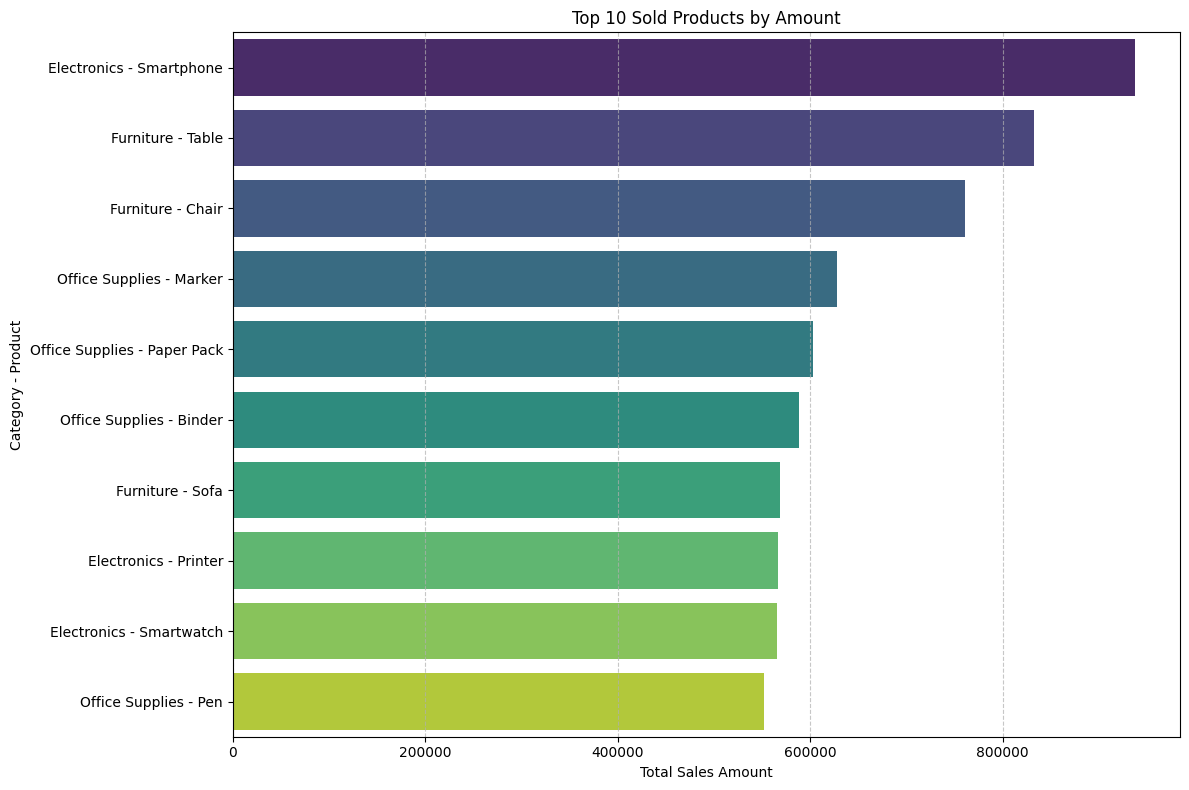

In [ ]:


# The 'pivot' DataFrame from a previous cell already contains total 'Amount' for each 'Category', 'Product',
# sorted by 'Amount' in descending order. We just need to take the top 10.
top_10_products = pivot.head(10).reset_index()

# Create a combined 'Category - Product' column for better plotting labels
top_10_products['Category_Product'] = top_10_products['Category'] + ' - ' + top_10_products['Product']

plt.figure(figsize=(12, 8))
sns.barplot(x='Amount', y='Category_Product', data=top_10_products, palette='viridis', hue='Category_Product', legend=False)
plt.title('Top 10 Sold Products by Amount')
plt.xlabel('Total Sales Amount')
plt.ylabel('Category - Product')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

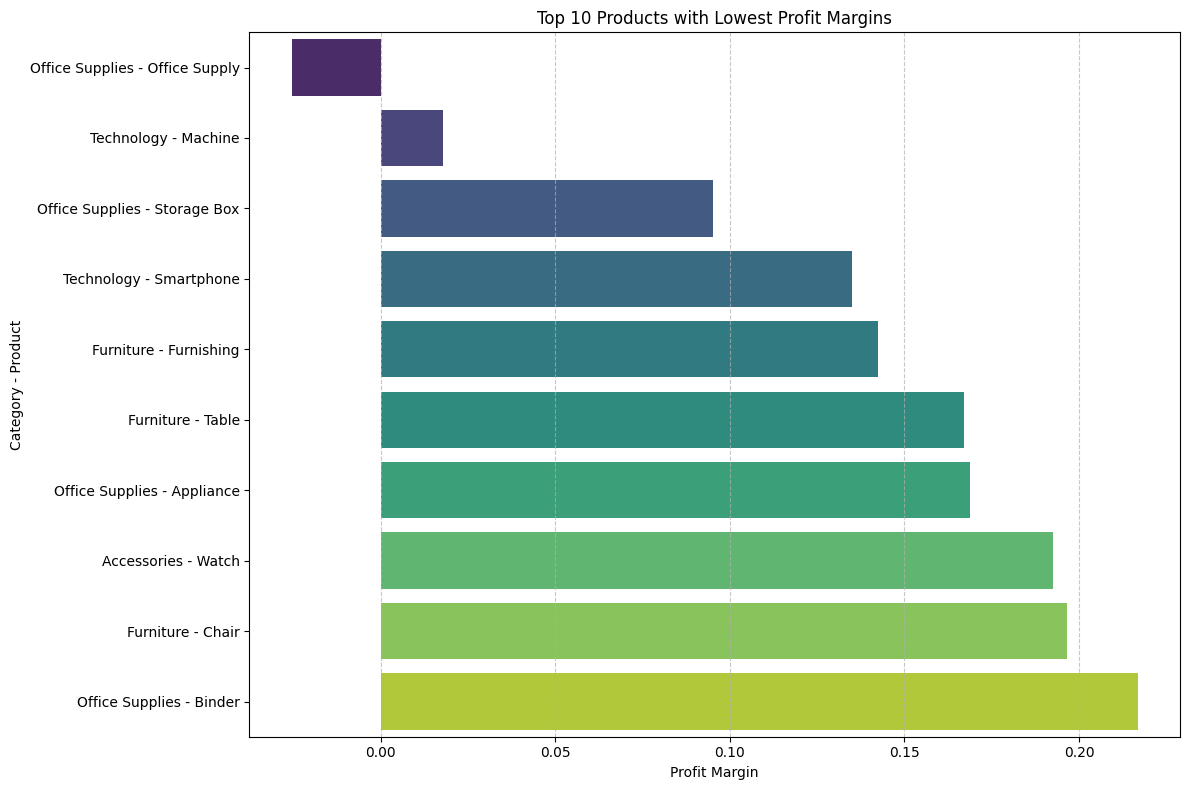

In [ ]:
# Ensure 'Category_Product' column exists for plotting
lowest_margin_products['Category_Product'] = lowest_margin_products['Category'] + ' - ' + lowest_margin_products['Product']

plt.figure(figsize=(12, 8))
sns.barplot(x='Profit_Margin', y='Category_Product', data=lowest_margin_products.head(10).sort_values(by='Profit_Margin', ascending=True), palette='viridis', hue='Category_Product', legend=False)
plt.title('Top 10 Products with Lowest Profit Margins')
plt.xlabel('Profit Margin')
plt.ylabel('Category - Product')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
df.describe(include='object')

,Order ID,Order Date,Year-Month,CustomerName,Segment,Category,Sub-Category,Product,PaymentMode,Ship Mode,City,State,Region,Country
count,11557,11557,11557,11557,11557,11557,11557,11557,11557,11557,11557,11557,11557,11557
unique,10910,1816,61,1347,3,8,27,34,5,4,531,49,4,1
top,B-25465,2022-07-16,2022-12,Joseph Smith,Consumer,Office Supplies,Binders,Binder,Credit Card,Standard Class,New York City,California,West,United States
freq,12,17,257,37,5997,6425,1618,1594,2600,6887,989,2281,3483,11557


In [ ]:
df.groupby(['State','Category'])['Profit'].sum().sort_values(ascending=False)

State           Category       
Florida         Electronics        138696.4300
New York        Office Supplies    134443.0829
California      Office Supplies    133694.3847
New York        Electronics        130575.0100
California      Furniture          124553.9656
                                      ...     
North Carolina  Furniture           -3486.4633
                Technology          -3583.3040
Pennsylvania    Office Supplies     -5172.0188
                Furniture           -7196.7199
Ohio            Technology         -12649.9401
Name: Profit, Length: 171, dtype: float64

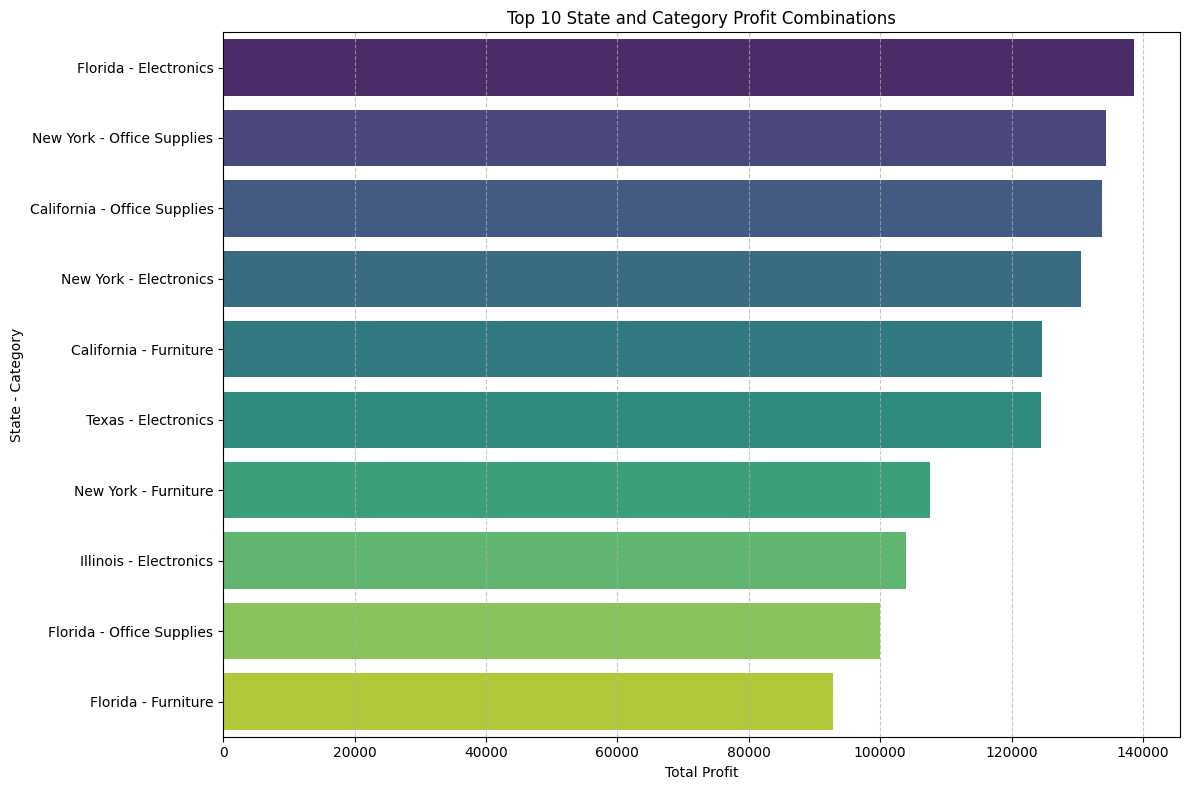

In [ ]:

# Group by State and Category and sum Profit, then sort and get top 10
top_10_profit_combinations = df.groupby(['State', 'Category'])['Profit'].sum().nlargest(10).reset_index()

# Create a combined 'State - Category' column for better plotting and to address the FutureWarning
top_10_profit_combinations['State_Category'] = top_10_profit_combinations['State'] + ' - ' + top_10_profit_combinations['Category']

plt.figure(figsize=(12, 8))
sns.barplot(x='Profit', y='State_Category', data=top_10_profit_combinations, palette='viridis', hue='State_Category', legend=False)
plt.title('Top 10 State and Category Profit Combinations')
plt.xlabel('Total Profit')
plt.ylabel('State - Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
office_supply_losses = df[(df['Category'] == 'Office Supplies') & (df['Product'] == 'Office Supply')]

print("Transactions for 'Office Supplies - Office Supply' (sorted by Profit):")
display(office_supply_losses.sort_values(by='Profit').head())

print("\nSummary Statistics for 'Office Supplies - Office Supply':")
display(office_supply_losses[['Quantity', 'Price', 'Amount', 'Discount', 'Profit']].describe())

Transactions for 'Office Supplies - Office Supply' (sorted by Profit):


,Order ID,Order Date,Year-Month,CustomerName,Segment,Category,Sub-Category,Product,Quantity,Price,Amount,Discount,Profit,PaymentMode,Ship Mode,City,State,Postal Code,Region,Country
3366,B-29172,2023-04-14,2023-04,Daniel Martinez,Consumer,Office Supplies,Supplies,Office Supply,7,832.81,4663.736,0.2,-1049.3406,Debit Card,Second Class,Philadelphia,Pennsylvania,19134.0,East,United States
6761,B-32567,2024-10-20,2024-10,Karen Jones,Consumer,Office Supplies,Supplies,Office Supply,3,1637.53,3930.072,0.2,-786.0144,COD,Standard Class,Round Rock,Texas,78664.0,Central,United States
6021,B-31827,2022-09-10,2022-09,Patricia Lee,Consumer,Office Supplies,Supplies,Office Supply,2,832.81,1332.496,0.2,-299.8116,Credit Card,Standard Class,Denver,Colorado,80219.0,West,United States
1851,B-27657,2020-03-24,2020-03,Charles Brown,Corporate,Office Supplies,Supplies,Office Supply,5,240.37,961.480,0.2,-204.3145,COD,Second Class,Tamarac,Florida,33319.0,South,United States
10879,B-36685,2024-11-12,2024-11,Barbara Wilson,Consumer,Office Supplies,Supplies,Office Supply,4,240.37,769.184,0.2,-163.4516,Credit Card,Standard Class,Philadelphia,Pennsylvania,19140.0,East,United States



Summary Statistics for 'Office Supplies - Office Supply':


,Quantity,Price,Amount,Discount,Profit
count,190.000000,190.000000,190.000000,190.000000,190.000000
mean,3.405263,75.544842,245.650200,0.076842,-6.258418
std,1.837002,248.234811,923.828753,0.097539,105.059628
min,1.000000,2.080000,1.744000,0.000000,-1049.340600
25%,2.000000,5.695000,12.124500,0.000000,0.437100
50%,3.000000,8.880000,27.930000,0.000000,3.959300
75%,5.000000,13.980000,55.492000,0.200000,9.085800
max,10.000000,1637.530000,8187.650000,0.200000,327.506000


In [ ]:
average_discount_office_supply = office_supply_losses['Discount'].mean()
print(f"Average Discount for 'Office Supplies - Office Supply': {average_discount_office_supply:.2f}")

Average Discount for 'Office Supplies - Office Supply': 0.08


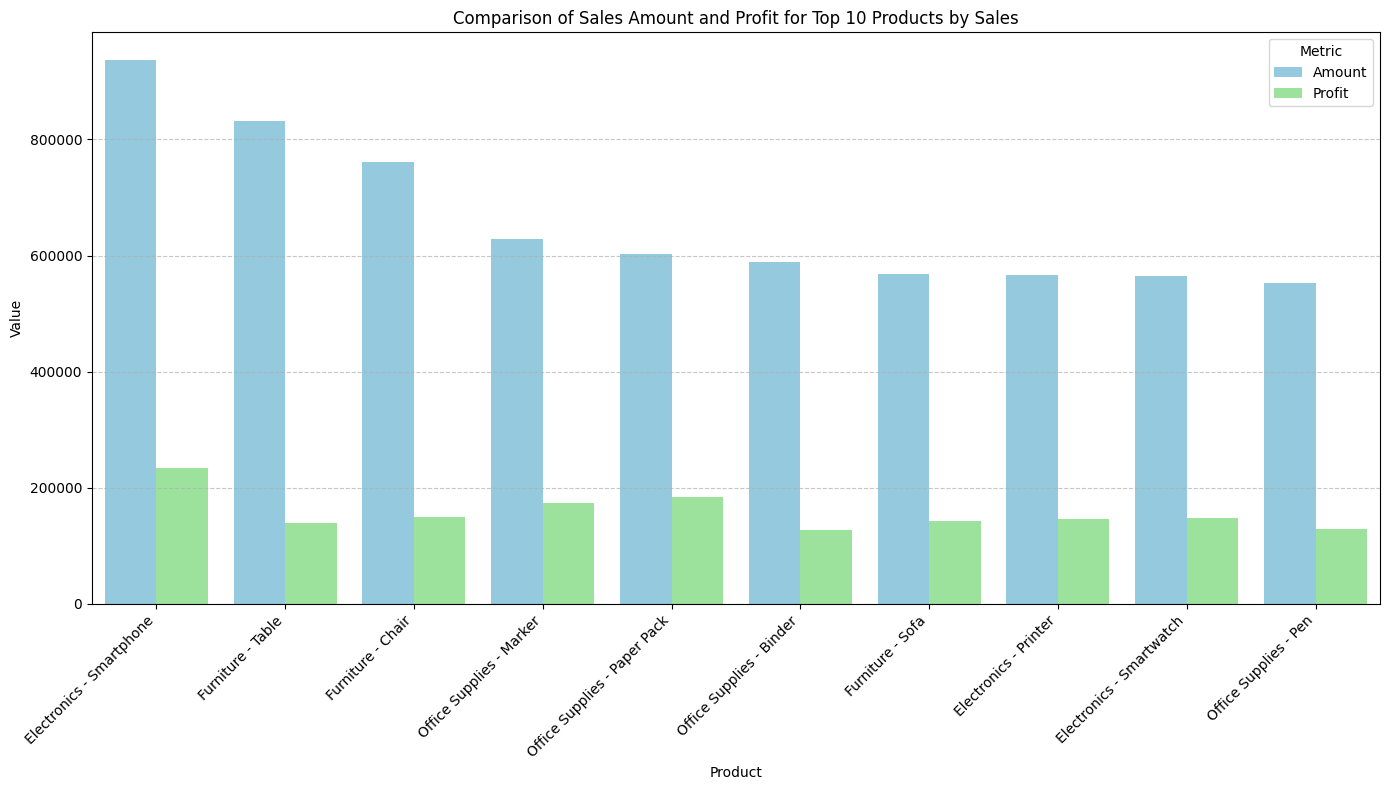

In [ ]:
# Ensure top_10_products is available (it should be from previous execution)
# Merge with profit_pivot to get profit for these top selling products
profit_for_top_sales = profit_pivot.loc[top_10_products[['Category', 'Product']].set_index(['Category', 'Product']).index].reset_index()

# Combine sales amount and profit for plotting
combined_sales_profit = top_10_products.merge(profit_for_top_sales, on=['Category', 'Product'], suffixes=('_Amount', '_Profit'))

# Melt the DataFrame for grouped bar plot
combined_sales_profit_melted = combined_sales_profit.melt(id_vars=['Category_Product'],
                                                            value_vars=['Amount', 'Profit'],
                                                            var_name='Metric',
                                                            value_name='Value')

plt.figure(figsize=(14, 8))
sns.barplot(x='Category_Product', y='Value', hue='Metric', data=combined_sales_profit_melted, palette={'Amount': 'skyblue', 'Profit': 'lightgreen'})
plt.title('Comparison of Sales Amount and Profit for Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
office_supply_negative_profit = df[(df['Category'] == 'Office Supplies') &
                                 (df['Product'] == 'Office Supply') &
                                 (df['Profit'] < 0)]

negative_profit_by_region = office_supply_negative_profit.groupby('Region')['Profit'].sum().sort_values(ascending=True)

print("Regions contributing to negative profit for 'Office Supplies - Office Supply':")
display(negative_profit_by_region)

Regions contributing to negative profit for 'Office Supplies - Office Supply':


,Profit
Region,
East,-1561.7735
Central,-860.2812
West,-344.6123
South,-248.9549


In [ ]:
office_supply_product_df = df[(df['Category'] == 'Office Supplies') &
                                (df['Product'] == 'Office Supply')]

regional_profit_margin = office_supply_product_df.groupby('Region').agg(
    Total_Amount=('Amount', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

regional_profit_margin['Profit_Margin'] = regional_profit_margin.apply(
    lambda row: (row['Total_Profit'] / row['Total_Amount']) if row['Total_Amount'] != 0 else 0,
    axis=1
)

print("Profit Margins for 'Office Supplies - Office Supply' by Region:")
display(regional_profit_margin.sort_values(by='Profit_Margin', ascending=True))

Profit Margins for 'Office Supplies - Office Supply' by Region:


,Region,Total_Amount,Total_Profit,Profit_Margin
1,East,10760.116,-1155.1352,-0.107353
0,Central,9467.372,-661.8881,-0.069913
2,South,8318.928,1.8773,0.000226
3,West,18127.122,626.0465,0.034536


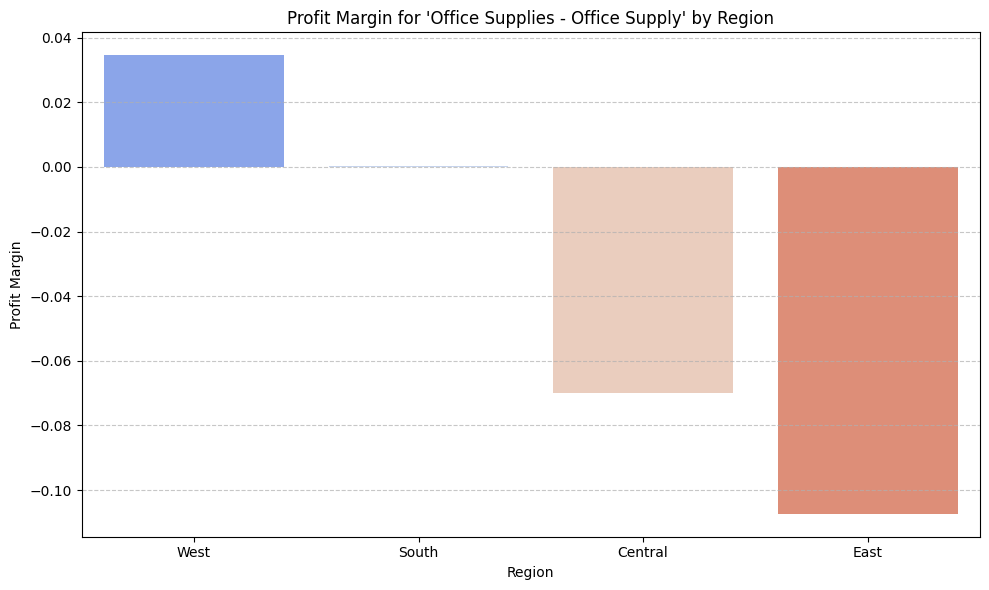

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Profit_Margin', data=regional_profit_margin.sort_values(by='Profit_Margin', ascending=False), palette='coolwarm', hue='Region', legend=False)
plt.title('Profit Margin for \'Office Supplies - Office Supply\' by Region')
plt.xlabel('Region')
plt.ylabel('Profit Margin')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
east_region_office_supply_transactions = df[
    (df['Category'] == 'Office Supplies') &
    (df['Product'] == 'Office Supply') &
    (df['Region'] == 'East')
]

print("Transactions for 'Office Supplies - Office Supply' in the East Region (sorted by Profit):")
display(east_region_office_supply_transactions.sort_values(by='Profit').head())

print("\nSummary Statistics for 'Office Supplies - Office Supply' in the East Region:")
display(east_region_office_supply_transactions[['Quantity', 'Price', 'Amount', 'Discount', 'Profit']].describe())

Transactions for 'Office Supplies - Office Supply' in the East Region (sorted by Profit):


,Order ID,Order Date,Year-Month,CustomerName,Segment,Category,Sub-Category,Product,Quantity,Price,Amount,Discount,Profit,PaymentMode,Ship Mode,City,State,Postal Code,Region,Country
3366,B-29172,2023-04-14,2023-04,Daniel Martinez,Consumer,Office Supplies,Supplies,Office Supply,7,832.81,4663.736,0.2,-1049.3406,Debit Card,Second Class,Philadelphia,Pennsylvania,19134.0,East,United States
10879,B-36685,2024-11-12,2024-11,Barbara Wilson,Consumer,Office Supplies,Supplies,Office Supply,4,240.37,769.184,0.2,-163.4516,Credit Card,Standard Class,Philadelphia,Pennsylvania,19140.0,East,United States
2092,B-27898,2023-07-01,2023-07,Nancy Robinson,Consumer,Office Supplies,Supplies,Office Supply,1,832.81,666.248,0.2,-149.9058,UPI,Standard Class,Philadelphia,Pennsylvania,19134.0,East,United States
7820,B-33626,2024-03-16,2024-03,Karen Davis,Corporate,Office Supplies,Supplies,Office Supply,2,240.37,384.592,0.2,-81.7258,EMI,Second Class,Columbus,Ohio,43229.0,East,United States
5553,B-31359,2021-05-11,2021-05,Daniel Jackson,Consumer,Office Supplies,Supplies,Office Supply,3,119.31,286.344,0.2,-64.4274,Debit Card,Standard Class,Lancaster,Pennsylvania,17602.0,East,United States



Summary Statistics for 'Office Supplies - Office Supply' in the East Region:


,Quantity,Price,Amount,Discount,Profit
count,56.000000,56.000000,56.000000,56.000000,56.000000
mean,3.482143,61.738036,192.144929,0.067857,-20.627414
std,1.935234,161.495585,640.215652,0.095550,144.371703
min,1.000000,2.180000,3.488000,0.000000,-1049.340600
25%,2.000000,5.680000,11.461500,0.000000,0.591100
50%,3.000000,8.725000,27.565000,0.000000,4.333550
75%,5.000000,14.357500,69.655000,0.200000,8.663400
max,10.000000,832.810000,4663.736000,0.200000,36.813000


In [ ]:
average_discount_east_region = east_region_office_supply_transactions['Discount'].mean()
print(f"Average Discount for 'Office Supplies - Office Supply' in the East Region: {average_discount_east_region:.2f}")

Average Discount for 'Office Supplies - Office Supply' in the East Region: 0.07


In [ ]:
office_supplies_df = df[df['Category'] == 'Office Supplies']

correlation_matrix_office_supplies = office_supplies_df[['Discount', 'Profit']].corr()
display(correlation_matrix_office_supplies)

,Discount,Profit
Discount,1.000000,-0.059459
Profit,-0.059459,1.000000


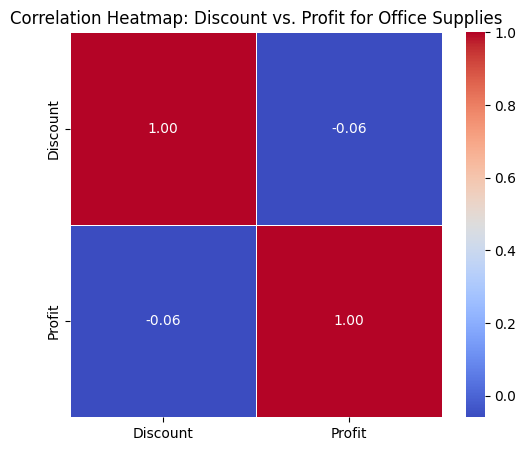

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix_office_supplies, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap: Discount vs. Profit for Office Supplies')
plt.show()

From our previous steps, we have the following data:

Average Discount by Region:

Region	Discount (Average)
East	0.158
Central	0.157
South	0.148
West	0.138
Profit Margins for 'Office Supplies - Office Supply' by Region:

Region	Profit_Margin
East	-0.107353
Central	-0.069913
South	0.000226
West	0.034536
Observations and Impact:

Inverse Relationship: There appears to be a clear inverse relationship between the average discount applied in a region and the profit margin for 'Office Supplies - Office Supply'. Regions with higher average discounts tend to have lower (or negative) profit margins for this product, and vice versa.
East Region: The East region has the highest average discount (0.158) and consequently the lowest profit margin (-10.7%). This strong negative correlation suggests that the high discounts in the East are a primary driver of the significant losses for 'Office Supplies - Office Supply' in this region.
Central Region: Similar to the East, the Central region has a high average discount (0.157), leading to a negative profit margin (-7.0%).
South Region: The South region applies a slightly lower average discount (0.148) and shows a near break-even profit margin (0.000226).
West Region: The West region applies the lowest average discount (0.138) among all regions and is the only one to achieve a positive profit margin (3.45%) for 'Office Supplies - Office Supply'. This strongly indicates that more controlled discounting strategies are beneficial for this product.
In summary, the variation in discount rates across regions has a direct and significant impact on the profitability of 'Office Supplies - Office Supply'. Regions with higher average discounts are experiencing substantial losses, while regions with more conservative discounting are managing to break even or even generate profit.

Building Machine Learning models to predict the Amount(Which shows the sales Linear regression Models)

In [ ]:
df.head()

,Order ID,Order Date,Year-Month,CustomerName,Segment,Category,Sub-Category,Product,Quantity,Price,Amount,Discount,Profit,PaymentMode,Ship Mode,City,State,Postal Code,Region,Country
0,B-26776,2023-06-27,2023-06,David Padilla,Consumer,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.15,1275.0,UPI,Second Class,Miami,Florida,33161.0,South,United States
1,B-26776,2024-12-27,2024-12,Connor Morgan,Home Office,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.00,1275.0,UPI,Standard Class,Chicago,Illinois,61761.0,Central,United States
2,B-26776,2021-07-25,2021-07,Robert Stone,Corporate,Electronics,Electronic Games,Smartwatch,5,1945.20,9726.0,0.20,1275.0,UPI,Standard Class,Buffalo,New York,13021.0,East,United States
3,B-26776,2023-06-27,2023-06,David Padilla,Corporate,Electronics,Printers,Printer,14,355.36,4975.0,0.00,1330.0,UPI,Standard Class,Miami,Florida,33317.0,South,United States
4,B-26776,2024-12-27,2024-12,Connor Morgan,Corporate,Electronics,Printers,Printer,14,355.36,4975.0,0.00,1330.0,UPI,Second Class,Chicago,Illinois,60423.0,Central,United States


In [ ]:
df['PaymentMode'].value_counts()

,count
PaymentMode,
Credit Card,2600
Debit Card,2468
UPI,2383
COD,2135
EMI,1971


In [ ]:
df.groupby('PaymentMode')['Profit'].sum().sort_values(ascending=False)

,Profit
PaymentMode,
Debit Card,504938.6415
Credit Card,449190.2046
UPI,433351.0085
EMI,367614.6928
COD,346829.5443


In [ ]:
df.groupby(['PaymentMode','State'])['Amount'].sum().sort_values(ascending=False)

PaymentMode  State        
Debit Card   New York         407938.6690
             California       359248.4010
Credit Card  California       358471.8890
UPI          New York         343393.7330
Debit Card   Texas            334344.6448
                                 ...     
EMI          Maine                29.8400
             North Dakota         21.5000
Credit Card  Montana               8.2880
Debit Card   West Virginia         6.2400
             North Dakota          2.4800
Name: Amount, Length: 235, dtype: float64

In [ ]:
df.groupby(['PaymentMode','Ship Mode'])['Amount'].sum().sort_values(ascending=False)

,,Amount
PaymentMode,Ship Mode,
Debit Card,Standard Class,1.182995e+06
UPI,Standard Class,1.133757e+06
Credit Card,Standard Class,1.128935e+06
COD,Standard Class,9.988041e+05
EMI,Standard Class,9.400216e+05
Debit Card,Second Class,4.407362e+05
UPI,Second Class,3.975112e+05
Debit Card,First Class,3.646311e+05
COD,Second Class,3.476620e+05


<Axes: xlabel='Segment,Ship Mode'>

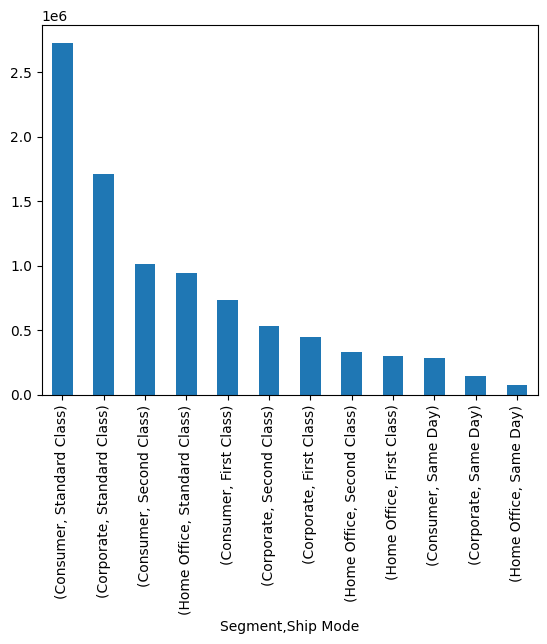

In [ ]:
df.groupby(['Segment','Ship Mode'])['Amount'].sum().sort_values(ascending=False).plot(kind='bar')

<Axes: xlabel='Segment,PaymentMode'>

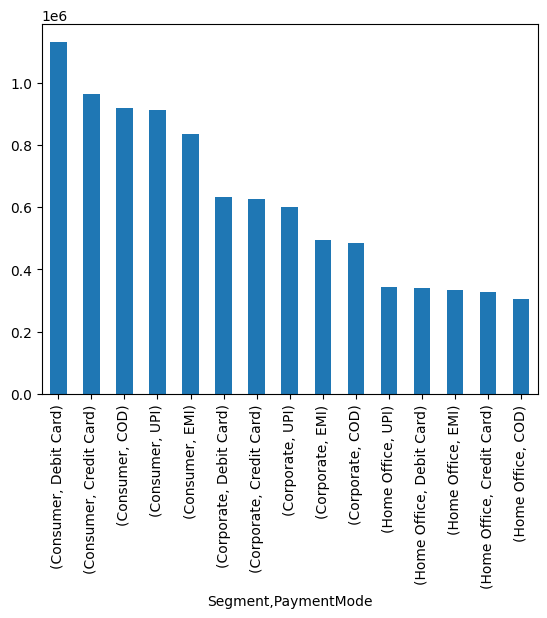

In [ ]:
df.groupby(['Segment','PaymentMode'])['Amount'].sum().sort_values(ascending=False).plot(kind='bar')

Building Models

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Drop irrelevant columns for modeling
df_model = df.drop(['Order ID', 'CustomerName', 'Year-Month', 'Product'], axis=1)

# Convert 'Order Date' to datetime and extract numerical features if desired
df_model['Order Date'] = pd.to_datetime(df_model['Order Date'])
df_model['Order_Day'] = df_model['Order Date'].dt.day
df_model['Order_Month'] = df_model['Order Date'].dt.month
df_model['Order_Year'] = df_model['Order Date'].dt.year
df_model = df_model.drop('Order Date', axis=1)

# Define target and features
X = df_model.drop('Amount', axis=1)
y = df_model['Amount']

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=np.number).columns

# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Create a pipeline that first preprocesses and then applies the Linear Regression model
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', LinearRegression())])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2 ): {r2:.2f}")

print("\nFirst 5 actual vs. predicted values:")
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(comparison_df.head())

Mean Squared Error (MSE): 648924.70
R-squared (R2 ): 0.83

First 5 actual vs. predicted values:


,Actual,Predicted
2452,149.950,112.675514
4561,95.968,215.671144
4537,244.006,657.745472
10533,151.188,-181.758659
2439,29.990,-243.077925


In [ ]:
# Install statsmodels for VIF calculation if not already installed
%pip install statsmodels

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Re-define preprocessor here to ensure it's a fresh object and correctly handles input
# (This is a workaround for a potential state/context issue with the previously fitted pipeline component)
numerical_transformer_vif = StandardScaler()
categorical_transformer_vif = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

preprocessor_vif = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_vif, numerical_cols),
        ('cat', categorical_transformer_vif, categorical_cols)
    ])

# Fit and transform X_train using this new preprocessor
X_train_processed = preprocessor_vif.fit_transform(X_train)

# Get feature names after one-hot encoding for categorical variables from this new preprocessor
categorical_cols_transformed = preprocessor_vif.named_transformers_['cat'].get_feature_names_out(categorical_cols)

# Combine numerical and transformed categorical feature names
all_features_names = numerical_cols.tolist() + categorical_cols_transformed.tolist()

# Convert the transformed data to a DataFrame
X_train_processed_df = pd.DataFrame(X_train_processed, columns=all_features_names)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_train_processed_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_processed_df.values, i) for i in range(len(X_train_processed_df.columns))]

print("Top 20 Features by VIF (indicating multicollinearity):")
display(vif_data.sort_values(by="VIF", ascending=False).head(20))

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Top 20 Features by VIF (indicating multicollinearity):


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,feature,VIF
619,Region_West,inf
618,Region_South,inf
617,Region_East,inf
616,Region_Central,inf
615,State_Wyoming,inf
614,State_Wisconsin,inf
597,State_New York,inf
596,State_New Mexico,inf
595,State_New Jersey,inf
594,State_New Hampshire,inf


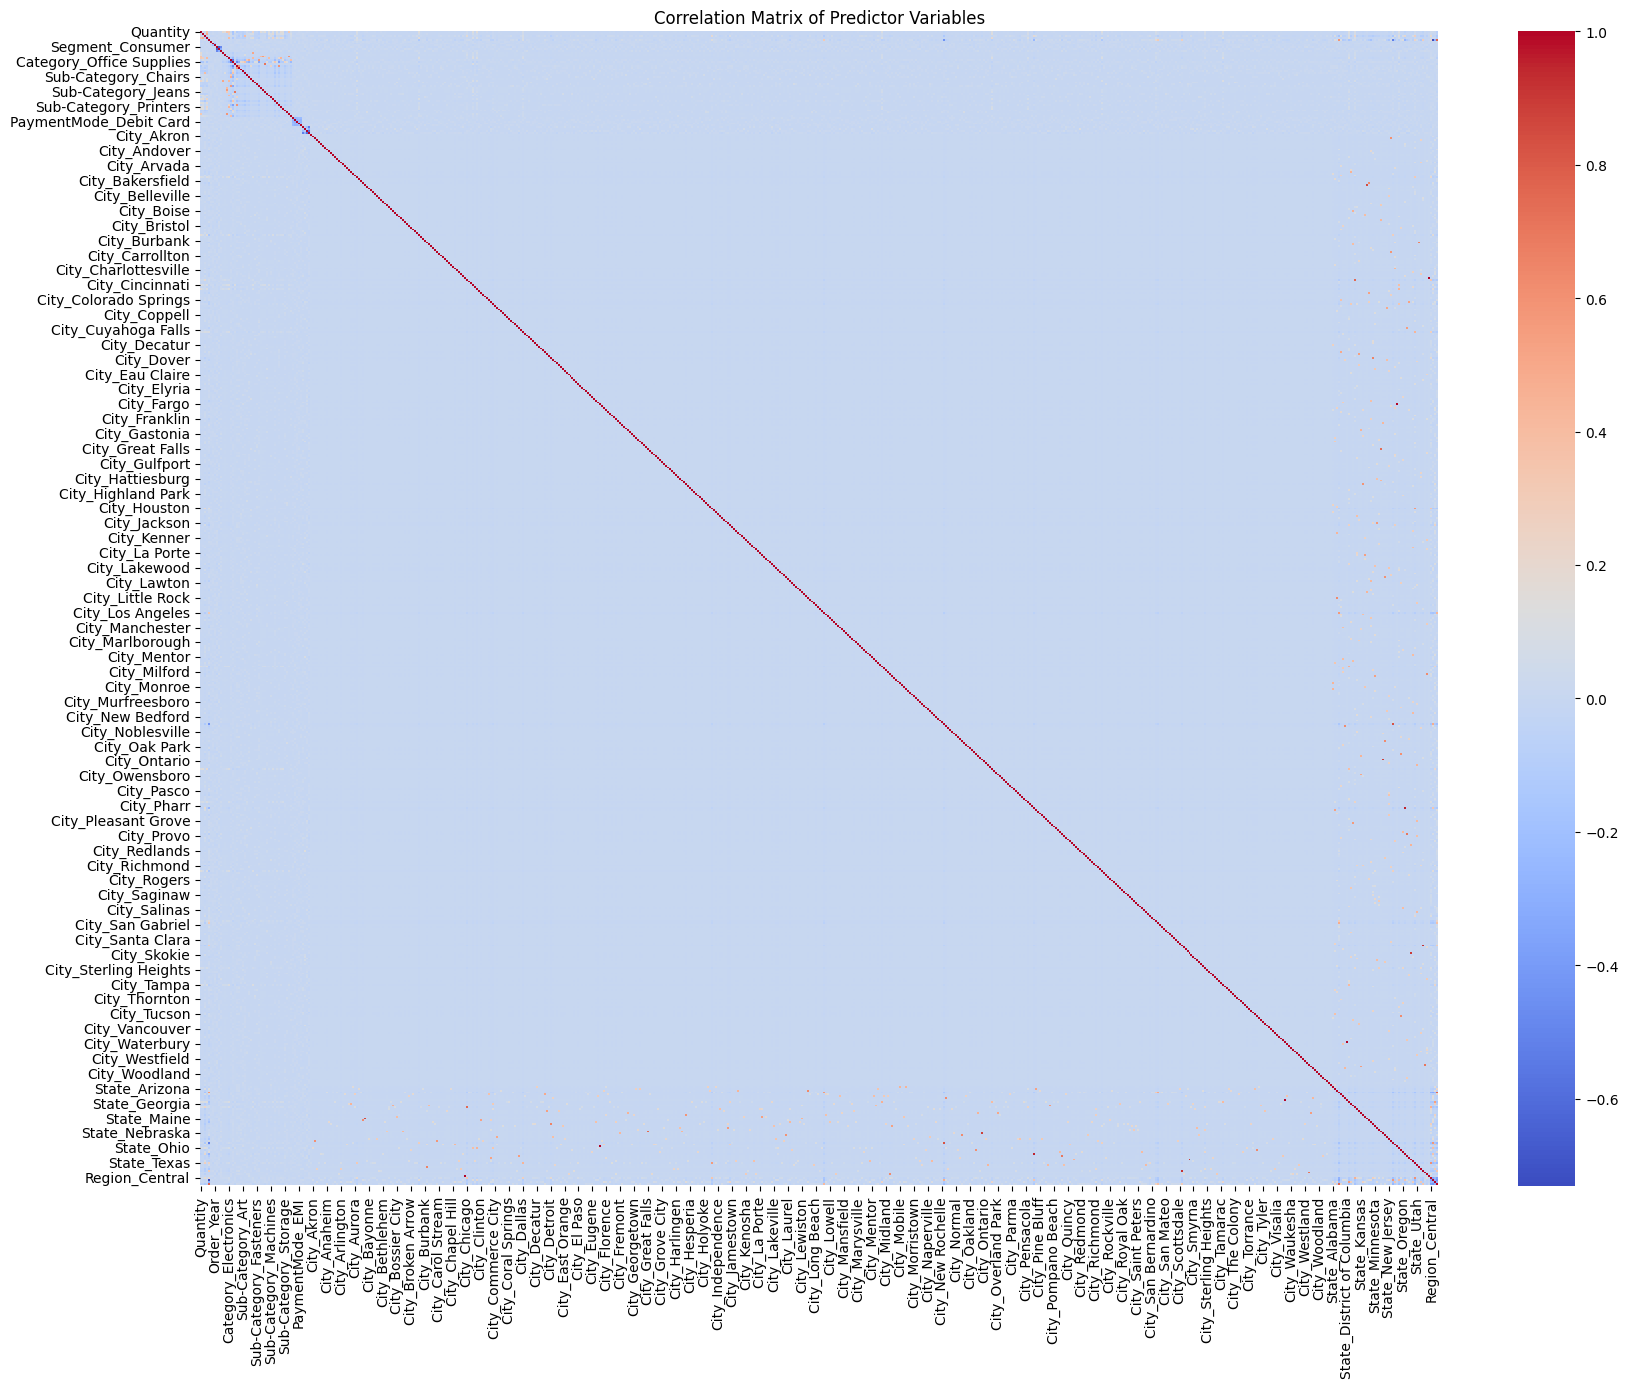

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 15))
sns.heatmap(X_train_processed_df.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Predictor Variables')
plt.show()